# Concentration-Based Stratified Sampling

To estimate $I=\int_{[0,1]^p} f(\mathbf{x})\,d\mathbf{x}$ we use adaptive **stratified sampling**:
the domain is partitioned into strata (axis-aligned boxes), a sampling budget is allocated across
them, and each stratum is sampled independently. The stratified estimator
$\hat I=\sum_i \mathrm{Vol}(A_i)\,\overline{f}_{A_i}$ is unbiased for any partition and allocation; a
good partition and allocation make its variance far smaller than crude Monte Carlo.

The partition is built **greedily and top-down**. We study two instances of the same scheme that
differ only in the quantity used to *score a split* and *allocate the budget*:

| | split objective | allocation |
|---|---|---|
| **Hoeffding** | $\sum \mathrm{Vol}\,(M-m)$ | $n \propto \mathrm{Vol}\,(M-m)$ |
| **Bernstein** | $\sum \mathrm{Vol}\,sd$ | $n \propto \mathrm{Vol}\,sd$ (Neyman) |

Here $M,m$ are the maximum/minimum of $f$ on a stratum and $sd$ its within-stratum standard
deviation; in $p$ dimensions a split also selects the cut coordinate (the one minimising the
objective).

**Hoeffding** needs the per-stratum extrema $M,m$, which we obtain by gradient ascent/descent from
randomly chosen box corners (exact for coordinate-wise monotone or convex $f$). **Bernstein** needs
no extrema: it estimates each $sd$ from a small **training sample**, splitting the budget as
$N=N_{train}+N_{est}$ with $N_{train}=\lfloor 0.1N\rceil$. Training points are used only to choose
the splits and the allocation; the integral is then estimated from **fresh** samples in each leaf,
so $\hat I$ remains unbiased.

**Stopping.** A stratum stops being split once its allocated estimation budget drops below $5\%$ of
$N$ (or a maximum depth is reached), yielding on the order of ten strata.

## Implementation

Run this cell first. It defines the two builders `split_hoeffding` and `split_bernstein`, the
stratified estimator `estimate`, a crude Monte Carlo baseline `mc_estimate`, and the helpers
`run_comparison`, `plot_splits_1d`, and `leaf_counts`. Every function is $p$-dimensional.

In [ ]:
"""Concentration-based stratified sampling on [0,1]^p  (thesis Chapter 2).

Clean, p-dimensional implementation.  Two top-level builders, `split_hoeffding`
and `split_bernstein`, share the same greedy top-down structure and the same
stopping rule (a stratum stops once its ALLOCATED estimation budget falls below
`thresh_frac * N`).  In 1D this reproduces the earlier results; nothing here is
specialised to one dimension.

Hoeffding extrema are found by gradient ascent / descent from randomly chosen
box corners (vectorised, no external optimiser) — exact for coordinate-wise
monotone / convex f, cheap otherwise.  Bernstein needs no extrema: it scores
splits with the empirical standard deviation of a small training sample.
"""
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt


# ======================================================================
# basic helpers
# ======================================================================
def _eval(f, X):
    """Evaluate f on a batch X of shape (n, p), returning shape (n,)."""
    return np.asarray(f(np.atleast_2d(X)), dtype=float)


def _sd(y):
    y = np.asarray(y, float)
    return float(y.std(ddof=1)) if y.size >= 2 else 0.0


@dataclass
class Region:
    """A leaf stratum: hyperrectangle [lo, hi] with allocated budget n."""
    lo: np.ndarray
    hi: np.ndarray
    n: int

    @property
    def vol(self):
        return float(np.prod(self.hi - self.lo))


def _alloc(w_left, w_right, n):
    """Split integer budget n by weights (Neyman); each side gets >= 1."""
    if w_left + w_right <= 0:
        nl = n // 2
    else:
        nl = int(round(n * w_left / (w_left + w_right)))
    nl = max(1, min(n - 1, nl))
    return nl, n - nl


# ======================================================================
# Hoeffding extrema:  GD / GA from randomly selected corners
# ======================================================================
def _corner_starts(lo, hi, n_corners, rng):
    """Up to `n_corners` box corners (always including all-lo and all-hi)."""
    p = len(lo)
    if 2 ** p <= n_corners:
        bits = (np.arange(2 ** p)[:, None] >> np.arange(p)) & 1
    else:
        bits = rng.integers(0, 2, size=(n_corners, p))
        bits = np.unique(np.vstack([bits, np.zeros(p, int), np.ones(p, int)]), axis=0)
    return lo + bits * (hi - lo)


def _extrema(f, lo, hi, rng, n_corners=8, n_steps=15):
    """Approximate (min, max) of f on the box [lo, hi].

    Gradient ascent (for the max) and descent (for the min) are run from the
    selected corners with a shrinking, scale-free sign step.  Vectorised over
    all corners at once.  For coordinate-wise monotone / convex f the corners
    already give the exact extrema, so the steps simply stay put.
    """
    lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    p = len(lo); span = hi - lo
    starts = _corner_starts(lo, hi, n_corners, rng)
    eps = np.maximum(1e-9, 1e-4 * span)

    def grad(X):
        g = np.empty_like(X)
        for d in range(p):
            Xp = X.copy(); Xp[:, d] = np.minimum(X[:, d] + eps[d], hi[d])
            Xm = X.copy(); Xm[:, d] = np.maximum(X[:, d] - eps[d], lo[d])
            g[:, d] = (_eval(f, Xp) - _eval(f, Xm)) / np.maximum(Xp[:, d] - Xm[:, d], 1e-12)
        return g

    def refine(sign):
        X = starts.copy(); step = 0.5 * span
        for _ in range(n_steps):
            X = np.clip(X + sign * step * np.sign(grad(X)), lo, hi)
            step = step * 0.7
        return X

    pts = np.vstack([starts, refine(+1.0), refine(-1.0)])
    v = _eval(f, pts)
    return float(v.min()), float(v.max())


# ======================================================================
# Greedy Hoeffding  (range objective, Eq. 2.7 / 2.11)
# ======================================================================
def split_hoeffding(f, lo, hi, N, depth=8, thresh_frac=0.10,
                    n_candidates=10, n_corners=8, n_steps=15, seed=0):
    rng = np.random.default_rng(seed)
    lo = np.asarray(lo, float); hi = np.asarray(hi, float); p = len(lo)
    thresh = thresh_frac * N
    leaves = []

    def recurse(rlo, rhi, n, d):
        if d <= 0 or n <= thresh or n < 2 or np.any(rhi - rlo <= 1e-12):
            leaves.append(Region(rlo, rhi, n)); return
        best = None
        for j in range(p):                                  # choose coordinate + location
            for t in np.linspace(rlo[j], rhi[j], n_candidates + 2)[1:-1]:
                hiL = rhi.copy(); hiL[j] = t
                loR = rlo.copy(); loR[j] = t
                mL, ML = _extrema(f, rlo, hiL, rng, n_corners, n_steps)
                mR, MR = _extrema(f, loR, rhi, rng, n_corners, n_steps)
                wl = float(np.prod(hiL - rlo)) * (ML - mL)
                wr = float(np.prod(rhi - loR)) * (MR - mR)
                if best is None or wl + wr < best[0]:
                    best = (wl + wr, j, float(t), wl, wr)
        _, j, t, wl, wr = best
        nl, nr = _alloc(wl, wr, n)
        hiL = rhi.copy(); hiL[j] = t
        loR = rlo.copy(); loR[j] = t
        recurse(rlo, hiL, nl, d - 1)
        recurse(loR, rhi, nr, d - 1)

    recurse(lo.copy(), hi.copy(), int(N), depth)
    return leaves


# ======================================================================
# Greedy Bernstein  (variance objective, Eq. 2.9 / 2.14)
# ======================================================================
def split_bernstein(f, lo, hi, N, depth=8, thresh_frac=0.10, train_frac=0.10,
                    n_candidates=10, min_side=2, seed=0):
    rng = np.random.default_rng(seed)
    lo = np.asarray(lo, float); hi = np.asarray(hi, float); p = len(lo)
    thresh = thresh_frac * N
    N_train = int(round(train_frac * N))
    N_est = N - N_train

    # one training draw over the whole domain; children only INHERIT it (no top-up)
    Sx = rng.uniform(lo, hi, size=(N_train, p))
    Sy = _eval(f, Sx)
    leaves = []

    def recurse(rlo, rhi, n, S, Sval, d):
        if (d <= 0 or n <= thresh or n < 2 or np.any(rhi - rlo <= 1e-12)
                or S.shape[0] < 2 * min_side):
            leaves.append(Region(rlo, rhi, n)); return
        best = None
        for j in range(p):                                  # choose coordinate + location
            order = np.argsort(S[:, j]); xs = S[order, j]
            cand = (xs[:-1] + xs[1:]) / 2.0
            if cand.size > n_candidates:
                cand = cand[np.round(np.linspace(0, cand.size - 1, n_candidates)).astype(int)]
            for t in cand:
                if not (rlo[j] < t < rhi[j]):
                    continue
                mL = S[:, j] <= t; mR = ~mL
                if mL.sum() < min_side or mR.sum() < min_side:
                    continue
                hiL = rhi.copy(); hiL[j] = t
                loR = rlo.copy(); loR[j] = t
                wl = float(np.prod(hiL - rlo)) * _sd(Sval[mL])
                wr = float(np.prod(rhi - loR)) * _sd(Sval[mR])
                if best is None or wl + wr < best[0]:
                    best = (wl + wr, j, float(t), wl, wr)
        if best is None:
            leaves.append(Region(rlo, rhi, n)); return
        _, j, t, wl, wr = best
        nl, nr = _alloc(wl, wr, n)
        mL = S[:, j] <= t; mR = ~mL
        hiL = rhi.copy(); hiL[j] = t
        loR = rlo.copy(); loR[j] = t
        recurse(rlo, hiL, nl, S[mL], Sval[mL], d - 1)
        recurse(loR, rhi, nr, S[mR], Sval[mR], d - 1)

    recurse(lo.copy(), hi.copy(), int(N_est), Sx, Sy, depth)
    return leaves


# ======================================================================
# estimator + crude Monte Carlo
# ======================================================================
def estimate(f, leaves, rng, prop_mix=0.0):
    ns = np.array([max(1, int(r.n)) for r in leaves], dtype=float)
    if prop_mix > 0.0 and len(leaves) > 1:
        vols = np.array([r.vol for r in leaves], dtype=float)
        N = ns.sum()
        q = (1.0 - prop_mix) * (ns / ns.sum()) + prop_mix * (vols / vols.sum())
        ns = np.maximum(1.0, np.round(N * q))
    total = 0.0
    for r, n in zip(leaves, ns):
        xs = rng.uniform(r.lo, r.hi, size=(int(n), len(r.lo)))
        total += r.vol * float(_eval(f, xs).mean())
    return total


def mc_estimate(f, lo, hi, N, rng):
    lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    xs = rng.uniform(lo, hi, size=(N, len(lo)))
    return float(np.prod(hi - lo) * _eval(f, xs).mean())


# ======================================================================
# experiment driver + plots
# ======================================================================
def run_comparison(f, lo, hi, Ns, true_I=None, *, trials=80, depth=8,
                   thresh_frac=0.10, n_candidates=10, train_frac=0.10,
                   n_steps=15, n_corners=8, metric="variance", seed=0, title=None, show=True, prop_mix=0.0):
    lo = np.asarray(lo, float); hi = np.asarray(hi, float)
    mc, hf, be = [], [], []
    for N in Ns:
        em = np.empty(trials); eh = np.empty(trials); eb = np.empty(trials)
        for t in range(trials):
            em[t] = mc_estimate(f, lo, hi, N, np.random.default_rng(seed + 1 + t))
            Lh = split_hoeffding(f, lo, hi, N, depth=depth, thresh_frac=thresh_frac,
                                 n_candidates=n_candidates, n_steps=n_steps,
                                 n_corners=n_corners, seed=seed + t)
            eh[t] = estimate(f, Lh, np.random.default_rng(seed + 10_000 + t), prop_mix=prop_mix)
            Lb = split_bernstein(f, lo, hi, N, depth=depth, thresh_frac=thresh_frac,
                                 train_frac=train_frac, n_candidates=n_candidates, seed=seed + t)
            eb[t] = estimate(f, Lb, np.random.default_rng(seed + 20_000 + t), prop_mix=prop_mix)
        agg = ((lambda e: float(np.sqrt(np.mean((e - true_I) ** 2)))) if metric == "rmse"
               else (lambda e: float(e.var(ddof=1))))
        mc.append(agg(em)); hf.append(agg(eh)); be.append(agg(eb))
    if show:
        plt.figure()
        plt.loglog(Ns, mc, "o-", label="Uniform MC")
        plt.loglog(Ns, hf, "s-", label="Greedy Hoeffding")
        plt.loglog(Ns, be, "^-", label="Greedy Bernstein")
        plt.xlabel("N (samples per estimator)")
        plt.ylabel("RMSE" if metric == "rmse" else "Estimator variance")
        plt.title(title or "comparison"); plt.legend(); plt.tight_layout(); plt.show()
    return {"N": list(Ns), "mc": mc, "hoeffding": hf, "bernstein": be}


def leaf_counts(f, lo, hi, N, **kw):
    seed = kw.pop("seed", 0)
    Lh = split_hoeffding(f, lo, hi, N, seed=seed,
                         **{k: kw[k] for k in ("depth", "thresh_frac", "n_candidates") if k in kw})
    Lb = split_bernstein(f, lo, hi, N, seed=seed,
                         **{k: kw[k] for k in ("depth", "thresh_frac", "n_candidates", "train_frac") if k in kw})
    return len(Lh), len(Lb)


def plot_splits_1d(f, N, *, method="hoeffding", seed=0, title=None, **kw):
    leaves = (split_hoeffding if method == "hoeffding" else split_bernstein)(
        f, [0.0], [1.0], N, seed=seed, **kw)
    leaves = sorted(leaves, key=lambda r: r.lo[0])
    rng = np.random.default_rng(seed + 999)
    xg = np.linspace(0, 1, 800)
    plt.figure(figsize=(8, 4.5))
    plt.plot(xg, _eval(f, xg[:, None]), "k-", lw=1.2, label="f(x)")
    for r in leaves[:-1]:
        plt.axvline(r.hi[0], ls="--", alpha=0.4)
    for r in leaves:
        xs = rng.uniform(r.lo[0], r.hi[0], size=max(1, r.n))
        plt.scatter(xs, _eval(f, xs[:, None]), s=10, alpha=0.7,
                    label=f"[{r.lo[0]:.2f},{r.hi[0]:.2f}] n={r.n}")
    tag = "Greedy Hoeffding" if method == "hoeffding" else "Greedy Bernstein"
    plt.title(title or f"{tag}: {len(leaves)} strata (N={N})")
    plt.xlabel("x"); plt.ylabel("f(x) and sampled points")
    plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()
    return leaves


## Computational efficiency

The cost of the Hoeffding builder is dominated by estimating the extrema $M,m$ on each candidate
sub-stratum. A direct approach would use uniform points in the strata, and perform gradient descent and gradient ascent on randomly selected subet of corner. This is done at every candidate split, along every axis, at every node,
which becomes very expensive as the dimension grows. We design around this:

1. **Corners, not interior search.** For coordinate-wise monotone or convex $f$ — the setting the
   method targets (e.g. networks with non-negative weights) — the extrema are attained at the box
   corners, so they follow from a few evaluations rather than an optimisation. A light gradient
   ascent/descent from the corners refines them for mildly non-monotone $f$.
2. **Vectorised evaluation.** All corner starts and finite-difference gradient probes are evaluated
   in single batched calls to $f$.
3. **Capped corners.** In high dimension we use a random subset of `n_corners` corners (default 8)
   rather than all $2^p$, so the per-split cost does not grow exponentially with $p$.
4. **Lightweight refinement.** A few shrinking sign-steps replace a full restarted solver.

Together these keep a $p$-dimensional build to seconds. Tunable knobs: `n_candidates`, `n_steps`,
`n_corners`, `thresh_frac` (which sets the number of strata) and `trials`. For a genuinely
monotone/convex $f$, setting `n_steps=0` makes the corners exact and removes all iteration.

## Example 1 — monotone integrand: $f(x)=e^{10x}$ on $[0,1]$

With a monotone integrand the corner extrema are exact, so Hoeffding operates in its ideal setting.
The range-to-sd ratio is essentially constant across strata, so the two methods choose nearly the
same partition and allocation; Hoeffding has the edge because it spends its whole budget on
estimation, whereas Bernstein sets aside $10\%$ for training.

strata at N=2048: (15, 14)


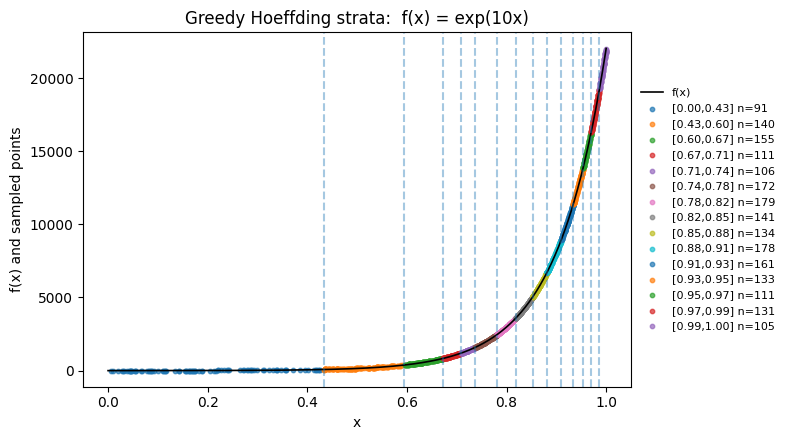

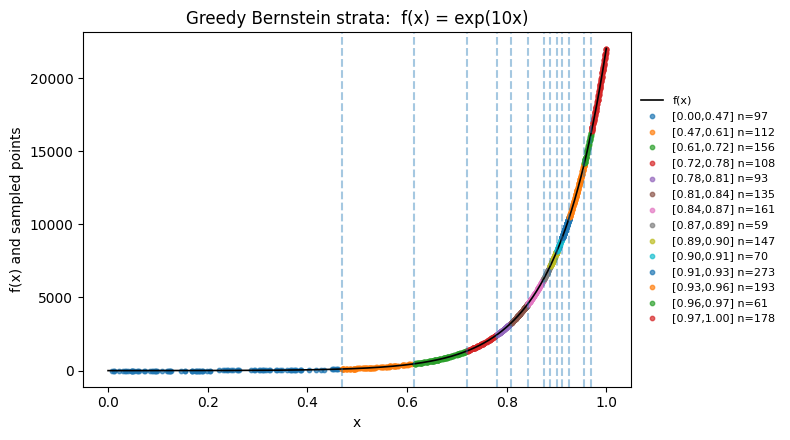

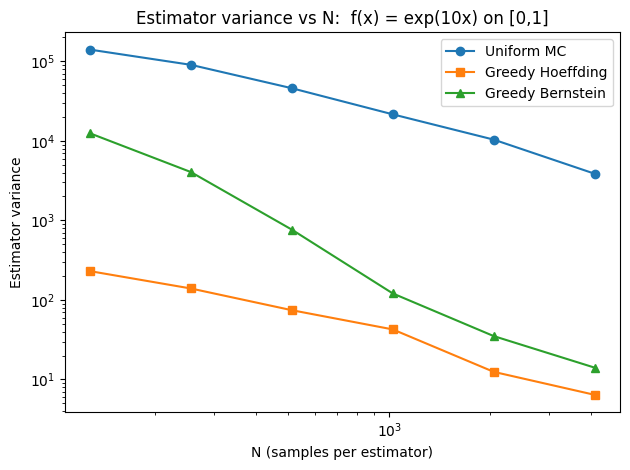

In [2]:
import numpy as np, math, matplotlib.pyplot as plt

f_mono = lambda x: np.exp(10*x[:, 0])
I_mono = (math.exp(10) - 1)/10
Ns = [128, 256, 512, 1024, 2048, 4096]

print("strata at N=2048:", leaf_counts(f_mono, [0.0], [1.0], 2048, thresh_frac=0.10, seed=2))
plot_splits_1d(f_mono, 2048, method="hoeffding", thresh_frac=0.10, seed=2,
               title="Greedy Hoeffding strata:  f(x) = exp(10x)")
plot_splits_1d(f_mono, 2048, method="bernstein", thresh_frac=0.10, seed=2,
               title="Greedy Bernstein strata:  f(x) = exp(10x)")

res_mono = run_comparison(f_mono, [0.0], [1.0], Ns, I_mono, trials=60,
                          metric="variance", title="Estimator variance vs N:  f(x) = exp(10x) on [0,1]")


## Example 2 — a non-monotone integrand on $[0,1]$

$$f(x)=\begin{cases}\tfrac12\,(1+\sin 24\pi x), & x<\tfrac12,\\[2pt](x-\tfrac12)^2+\tfrac12, & x\ge\tfrac12.\end{cases}$$

An oscillatory left half joined to a smooth right half. The range-to-sd ratio now varies across the
domain, so the variance-based Bernstein allocation departs from the range-based Hoeffding one and
Bernstein attains the lower estimator variance.

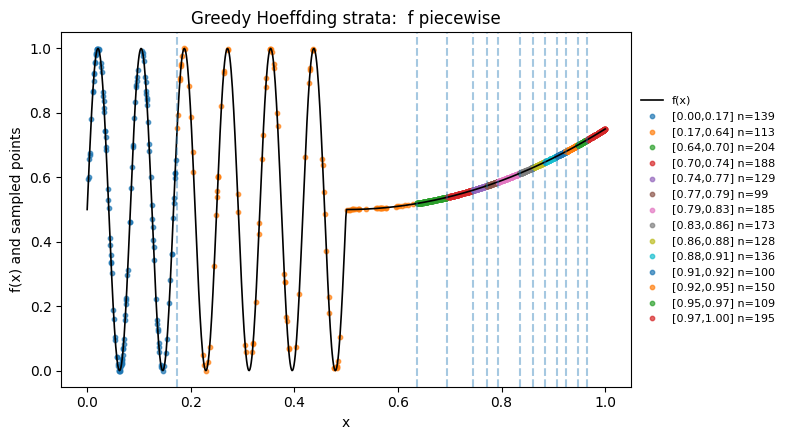

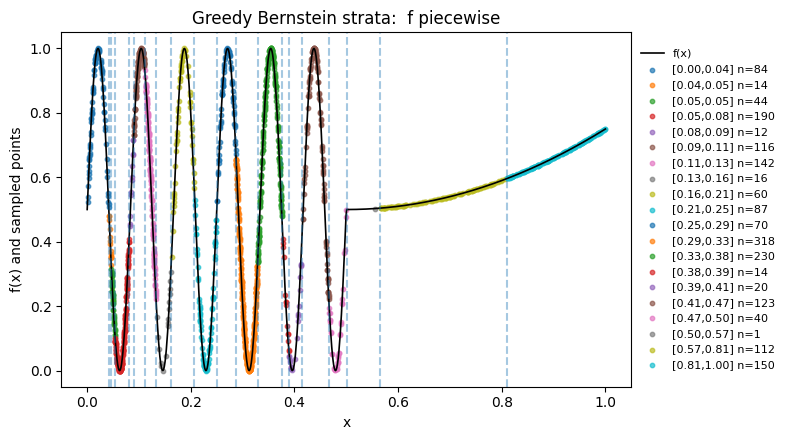

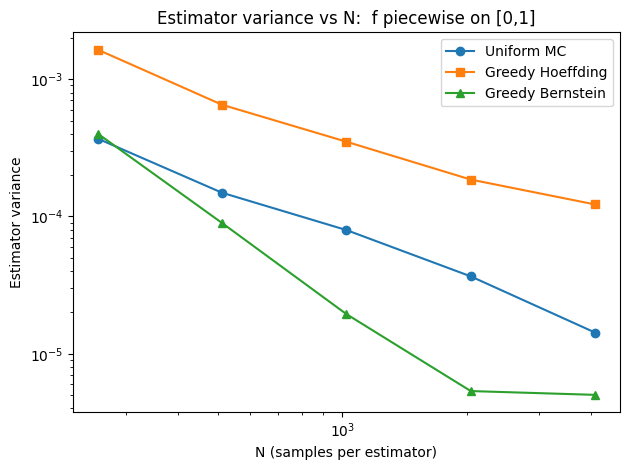

variance ratio Hoeffding/Bernstein: [4.09, 7.27, 18.02, 34.73, 24.38]


In [3]:
def f_gen(x):
    z = x[:, 0]
    return np.where(z < 0.5, 0.5*(1 + np.sin(24*np.pi*z)), (z - 0.5)**2 + 0.5)

I_gen = float(f_gen(np.linspace(0, 1, 2_000_001)[:, None]).mean())
Ns = [256, 512, 1024, 2048, 4096]

plot_splits_1d(f_gen, 2048, method="hoeffding", thresh_frac=0.10, seed=2,
               title="Greedy Hoeffding strata:  f piecewise")
plot_splits_1d(f_gen, 2048, method="bernstein", thresh_frac=0.10, seed=2,
               title="Greedy Bernstein strata:  f piecewise")

res_gen = run_comparison(f_gen, [0.0], [1.0], Ns, I_gen, trials=60,
                         metric="variance", title="Estimator variance vs N:  f piecewise on [0,1]")
print("variance ratio Hoeffding/Bernstein:",
      [round(h/b, 2) for h, b in zip(res_gen['hoeffding'], res_gen['bernstein'])])


## Example 3 — monotone integrand in $p$ dimensions

Separable, coordinate-wise increasing and convex: $f(\boldsymbol{x})=\sum_{j=1}^p0.4^{j-1} e^{10 x_j}$. The extrema
of every sub-box are attained at its corners, so we set `n_steps=0`: the corner evaluations are then
**exact** and the Hoeffding build does no gradient iteration at all — this is the regime the corner
rule is built for. With the range-to-sd ratio constant the two methods give comparable variance, and
both improve substantially on crude Monte Carlo.

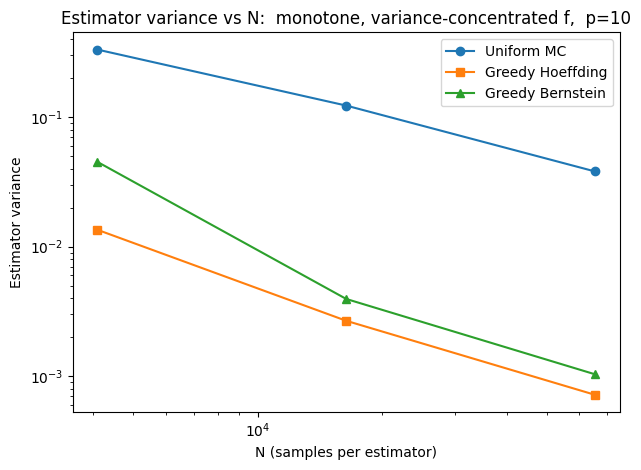

p=10  MC/Hoeff: [24.6, 45.9, 53.0]  MC/Bern: [7.4, 31.1, 36.8]


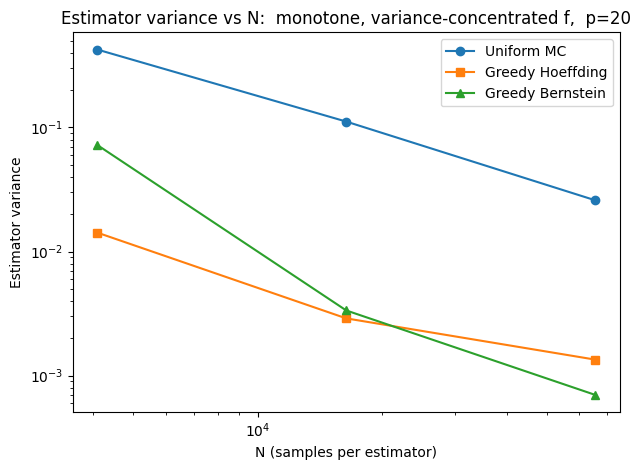

p=20  MC/Hoeff: [29.9, 38.6, 19.3]  MC/Bern: [5.9, 33.3, 37.1]


In [ ]:
def make_mono_conc(p, c=0.4, a=5.0):
    # monotone, convex, variance concentrated in the first coordinates (geometric weights)
    w = c**np.arange(p)
    return (lambda x: (np.exp(a*x) * w).sum(axis=1)), w

Ig = (np.exp(5.0) - 1)/5.0   # integral of exp(5 z) on [0,1]

for p in (10, 20):
    f, w = make_mono_conc(p)
    res = run_comparison(f, [0.0]*p, [1.0]*p, [4096, 16384, 65536], w.sum()*Ig,
                         depth=10, thresh_frac=0.05, train_frac=0.05,
                         trials=40, n_candidates=8, n_steps=0, metric="variance",
                         title=f"Estimator variance vs N:  monotone, variance-concentrated f,  p={p}")
    print(f"p={p}  MC/Hoeff:", [round(m/h, 1) for m, h in zip(res['mc'], res['hoeffding'])],
          " MC/Bern:", [round(m/b, 1) for m, b in zip(res['mc'], res['bernstein'])])

## Example 4 — non-monotone integrand in $p$ dimensions

Separable piecewise: $f(\mathbf{x})=\sum_{j=1}^p 0.4^{j-1}h(x_j)$ with $h$ the function of Example 2, so $f$ is
non-monotone in every coordinate. Bernstein attains lower variance than Hoeffding at both $p=5$ and
$p=10$. Two points matter in high dimension:

- The 5% budget threshold produces only ~10 strata **in total**, shared across all $p$ axes, so most
  coordinates are never cut. Stratification therefore helps less as $p$ grows: at $p=10$ the gain over
  crude MC is small (compare the MC line in the plot). A smaller `thresh_frac` (more strata) restores
  the advantage, at higher cost.
- Hoeffding searches every axis at every node, so its build time grows quickly with $p$; the $p=10$
  sweep uses reduced settings and is the slow cell (a few minutes).

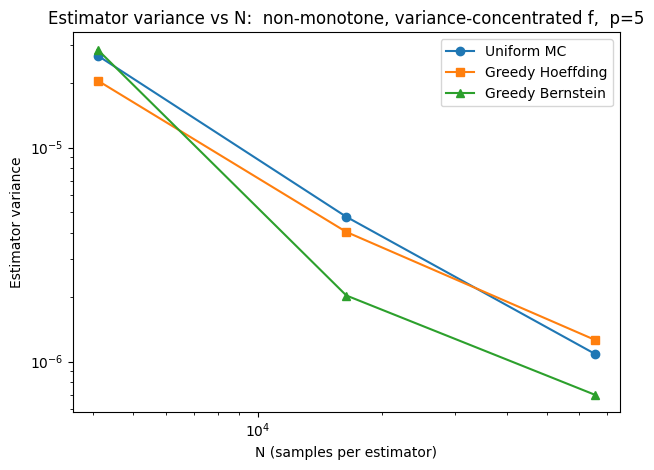

p=5  MC/Hoeff: [1.31, 1.18, 0.86]  MC/Bern: [0.94, 2.33, 1.55]


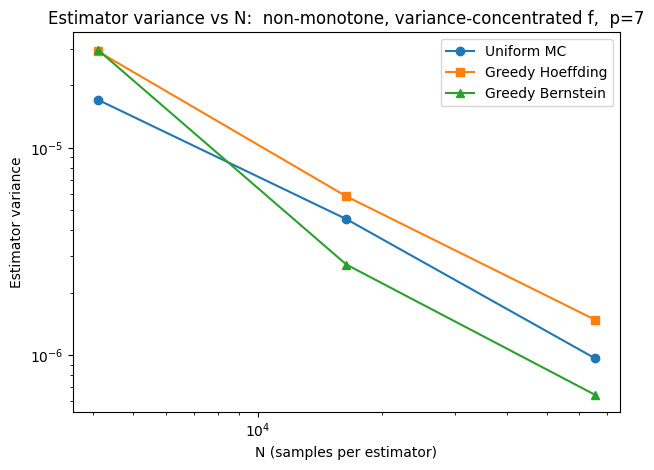

p=7  MC/Hoeff: [0.58, 0.78, 0.65]  MC/Bern: [0.57, 1.66, 1.5]


In [ ]:
def h(z):
    return np.where(z < 0.5, 0.5*(1 + np.sin(24*np.pi*z)), (z - 0.5)**2 + 0.5)

def make_conc(p, c=0.4):                 # variance concentrated in the first few coordinates
    w = c**np.arange(p)
    return (lambda x: (h(x) * w).sum(axis=1)), w

Ih = float(h(np.linspace(0, 1, 200001)).mean())

for p in (5, 7):
    f, w = make_conc(p)
    res = run_comparison(f, [0.0]*p, [1.0]*p, [4096, 16384, 65536], w.sum()*Ih,
                         depth=8, thresh_frac=0.05, train_frac=0.05,
                         trials=60, n_candidates=5, n_steps=8, metric="variance",
                         title=f"Estimator variance vs N:  non-monotone, variance-concentrated f,  p={p}")
    print(f"p={p}  MC/Hoeff:", [round(m/hh,2) for m,hh in zip(res['mc'],res['hoeffding'])],
          " MC/Bern:", [round(m/bb,2) for m,bb in zip(res['mc'],res['bernstein'])])

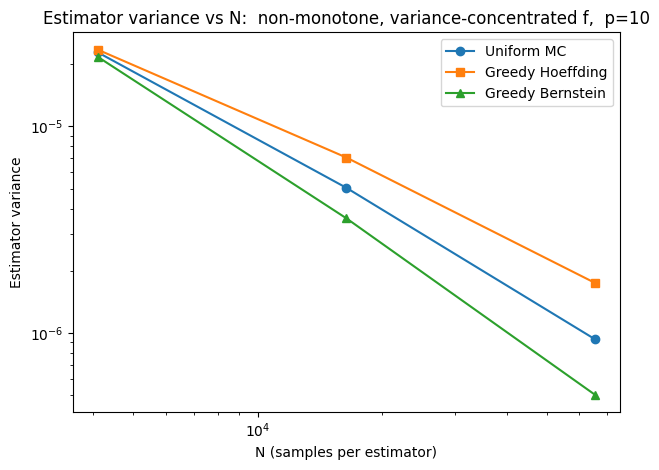

p=10  MC/Hoeff: [0.97, 0.71, 0.53]  MC/Bern: [1.05, 1.4, 1.86]


KeyboardInterrupt: 

In [ ]:
def h(z):
    return np.where(z < 0.5, 0.5*(1 + np.sin(24*np.pi*z)), (z - 0.5)**2 + 0.5)

def make_conc(p, c=0.4):                 # variance concentrated in the first few coordinates
    w = c**np.arange(p)
    return (lambda x: (h(x) * w).sum(axis=1)), w

Ih = float(h(np.linspace(0, 1, 200001)).mean())

for p in (10, 20):
    f, w = make_conc(p)
    res = run_comparison(f, [0.0]*p, [1.0]*p, [4096, 16384, 65536], w.sum()*Ih,
                         depth=10, thresh_frac=0.05, train_frac=0.05,
                         trials=60, n_candidates=5, n_steps=8, metric="variance",
                         title=f"Estimator variance vs N:  non-monotone, variance-concentrated f,  p={p}")
    print(f"p={p}  MC/Hoeff:", [round(m/hh,2) for m,hh in zip(res['mc'],res['hoeffding'])],
          " MC/Bern:", [round(m/bb,2) for m,bb in zip(res['mc'],res['bernstein'])])